# ResNet-based model with the RadioML 2018A dataset

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
from src.dataset import *
from src.utils import *
from src.config import setup_environment

In [3]:
GLOBAL_SEED = 2026
setup_environment(seed=GLOBAL_SEED)

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
path = "/home/wicom/Descargas/" # adjust yours
file = "GOLD_XYZ_OSC.0001_1024.hdf5"
classes = RadioMLConfig.CLASSES
fs = RadioMLConfig.FS
X, Y, Z = load_dataset(path, file)

[INFO] Loaded Dataset | X:(2555904, 1024, 2) Y:(2555904, 24) Z:(2555904, 1) | dtype X:float32


In [5]:
X = normalize_rms(X)

In [6]:
# split: train/val/test: 0.7/0.15/0.15
X_train, Y_train, Z_train, X_val, Y_val, Z_val, X_test, Y_test, Z_test = split_dataset(X, Y, Z, 
                                                                                       val_size=0.15,
                                                                                       test_size=0.15)

In [7]:
print("[INFO] Dataset split done!")
print("Train:", X_train.shape, Y_train.shape, Z_train.shape)
print("Val:  ", X_val.shape,   Y_val.shape,   Z_val.shape)
print("Test: ", X_test.shape,  Y_test.shape,  Z_test.shape)

[INFO] Dataset split done!
Train: (1789132, 1024, 2) (1789132, 24) (1789132, 1)
Val:   (383386, 1024, 2) (383386, 24) (383386, 1)
Test:  (383386, 1024, 2) (383386, 24) (383386, 1)


In [ ]:
# use the tf.DATA API
BATCH_SIZE = 256
train_ds = build_tf_dataset(X_train, Y_train, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = build_tf_dataset(X_val,   Y_val,   batch_size=BATCH_SIZE, shuffle=False)
test_ds  = build_tf_dataset(X_test,  Y_test,  batch_size=BATCH_SIZE, shuffle=False)

print("[INFO] tf.data ok!")

In [8]:
# using PyDataset
BATCH_SIZE = 256
train_ds = PyDataset(X_train, Y_train, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = PyDataset(X_val,   Y_val,   batch_size=BATCH_SIZE, shuffle=False)
test_ds  = PyDataset(X_test,  Y_test,  batch_size=BATCH_SIZE, shuffle=False)

print("[INFO] PyDataset ok!")

[INFO] PyDataset ok!


In [9]:
from src.models.resnet import build_resnet_model
from src.evaluate import PlotLosses

In [10]:
plot_losses = PlotLosses()

In [11]:
%load_ext autoreload
%autoreload 2

In [ ]:
from src.train import lr_search
parameters_dict = {
    "input_shape": (1024, 2),
    "num_classes": 24,
    "name": "resnet_radioml2018"
}
lr_candidates = [1e-4, 3e-4, 1e-3, 3e-3]
best_lr = lr_search(lr_candidates, train_ds, val_ds, build_resnet_model, parameters_dict, 
                    epochs_per_trial=3, seed=GLOBAL_SEED)
# in this case: best_lr = 0.001

In [ ]:
from src.train import compile_model_with_lr
model = build_resnet_model(parameters_dict)
model = compile_model_with_lr(model, best_lr) 
model.summary()

In [ ]:
#Total params: 157,592 (615.59 KB)
#Trainable params: 157,592 (615.59 KB)
#Non-trainable params: 0 (0.00 B)

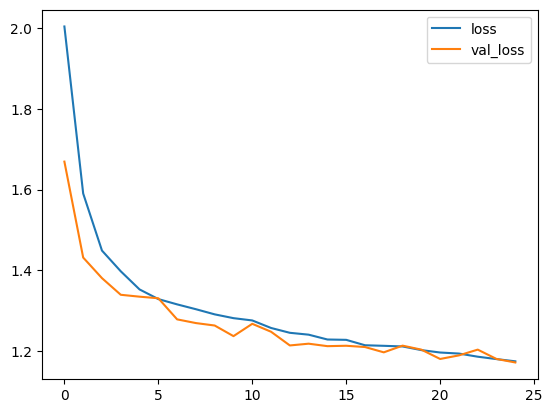

6989/6989 - 135s - 19ms/step - accuracy: 0.6084 - loss: 1.1740 - val_accuracy: 0.6090 - val_loss: 1.1711 - learning_rate: 3.8742e-04
Epoch 26/100


In [ ]:
from src.train import train_model
EPOCHS = 100
history, training_time = train_model(model=model, 
                                     train_ds=train_ds, 
                                     val_ds=val_ds,
                                     epochs=EPOCHS,
                                     plot_callback=plot_losses)

In [26]:
import pandas as pd
history_dict = pd.DataFrame(history.history)
display(history_dict)
history_dict.to_csv("./training_history_ResNet_RadioML2018A.csv", index=False)

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.317811,2.005014,0.404504,1.669629,0.001000
1,0.440506,1.590463,0.491434,1.431544,0.001000
2,0.491079,1.448848,0.512598,1.380422,0.001000
3,0.513270,1.397459,0.533392,1.339140,0.001000
4,0.533877,1.352431,0.542938,1.334432,0.001000
5,0.543117,1.328450,0.541553,1.330498,0.001000
6,0.550237,1.315335,0.564251,1.278122,0.001000
7,0.558917,1.303310,0.570728,1.268919,0.001000
8,0.565982,1.290547,0.578787,1.262844,0.001000
9,0.570418,1.281116,0.583096,1.236501,0.001000


In [ ]:
print("Save Model...", flush=True)
model.save("./Resnet1024_RadioML2018A.keras")

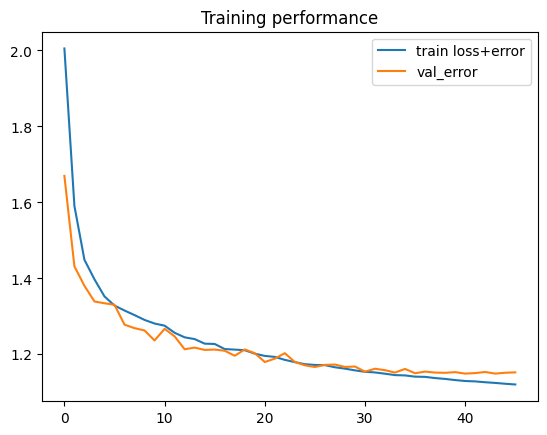

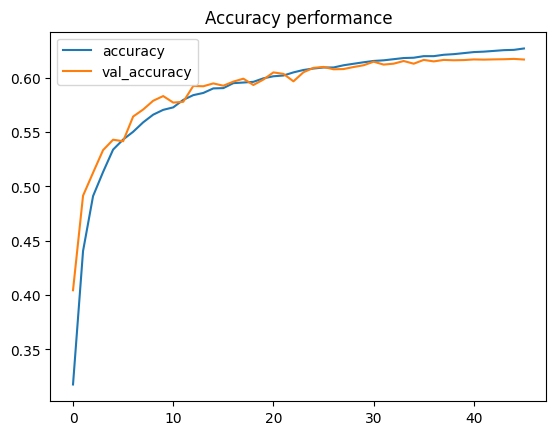

In [28]:
from src.evaluate import plot_loss, plot_accuracy

plot_loss(history)
plot_accuracy(history)

In [17]:
### TEST

I0000 00:00:1775129642.911386 3456999 service.cc:146] XLA service 0x79500c01b6a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775129642.911422 3456999 service.cc:154]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9


  30/1498 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6243 - loss: 1.1155

I0000 00:00:1775129648.937603 3456999 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1498/1498 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.6167 - loss: 1.1487
Test loss: 1.1487319469451904
Test accuracy: 0.616707444190979
457/457 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step


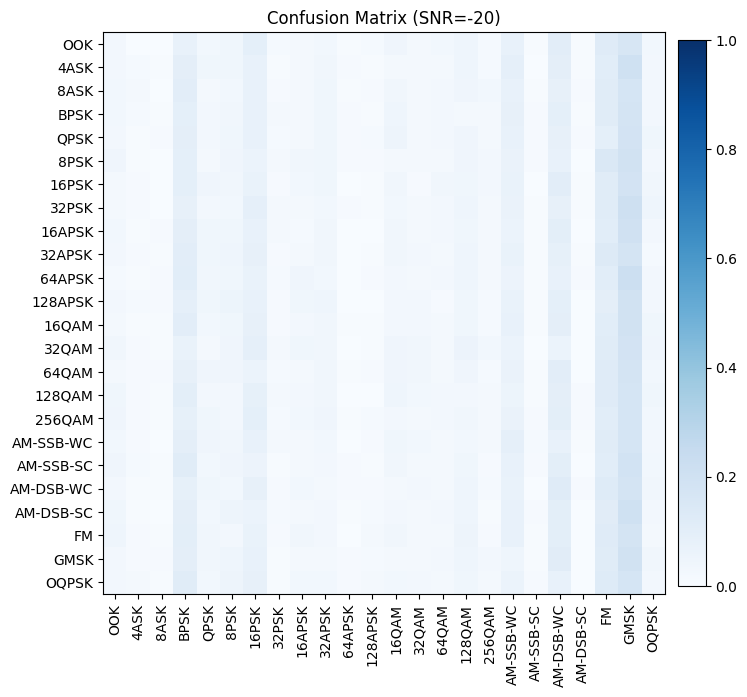

Overall Accuracy -20:  0.04260703050198331
459/459 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step


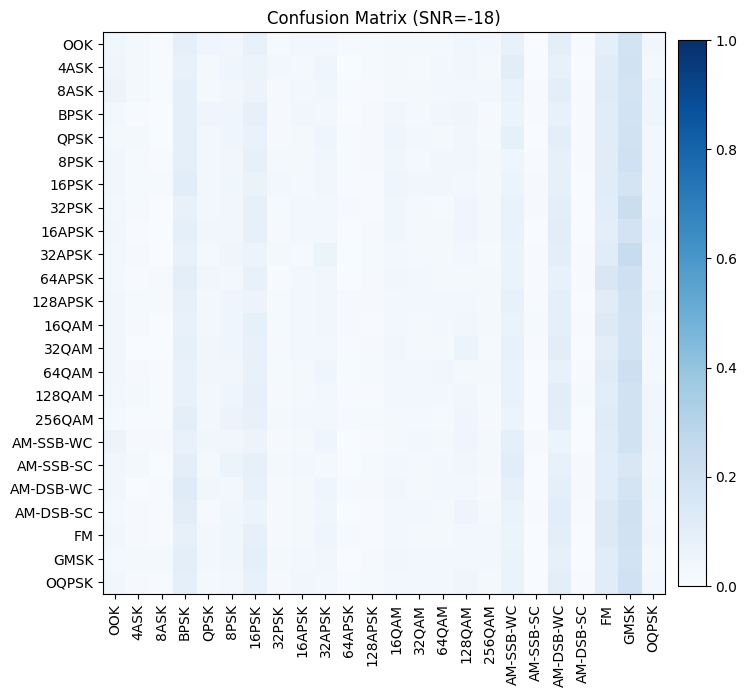

Overall Accuracy -18:  0.04253868702706388
457/457 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


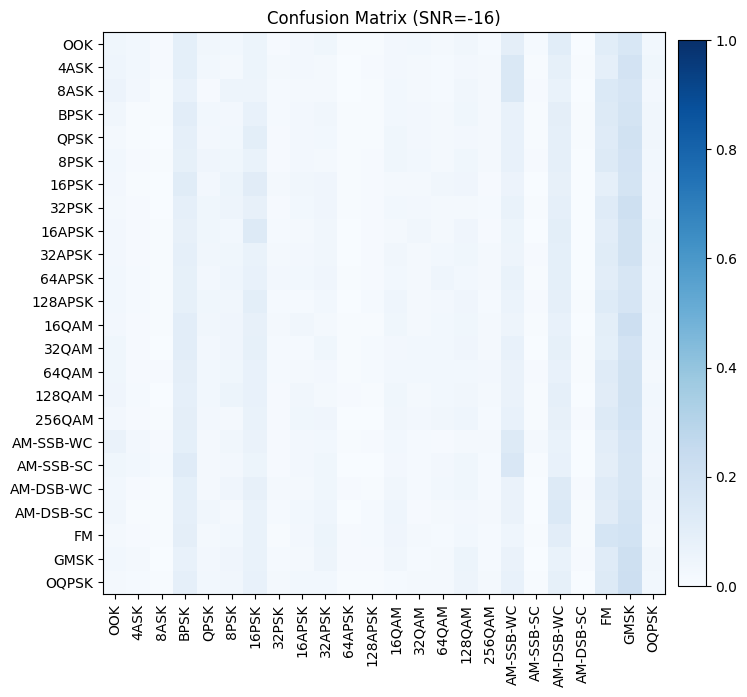

Overall Accuracy -16:  0.05180318894135359
463/463 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


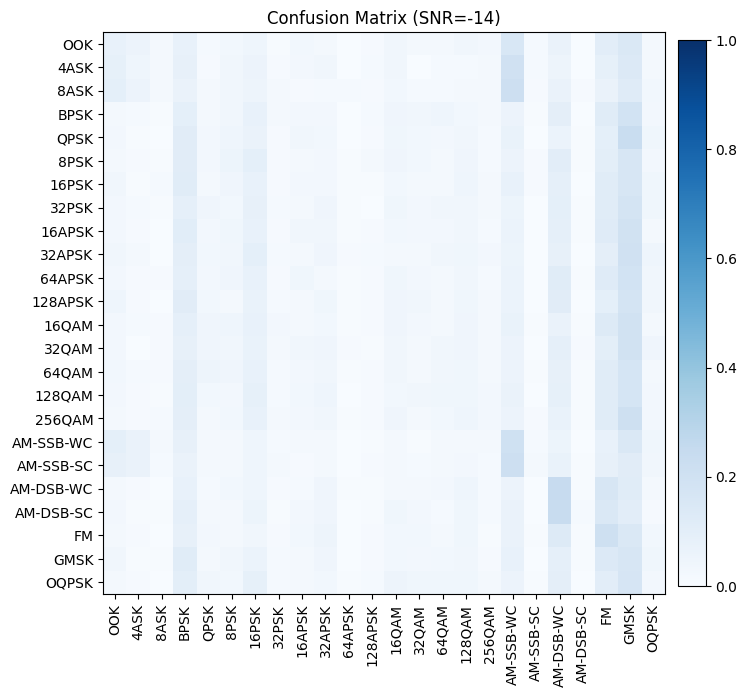

Overall Accuracy -14:  0.06347596836341513
457/457 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


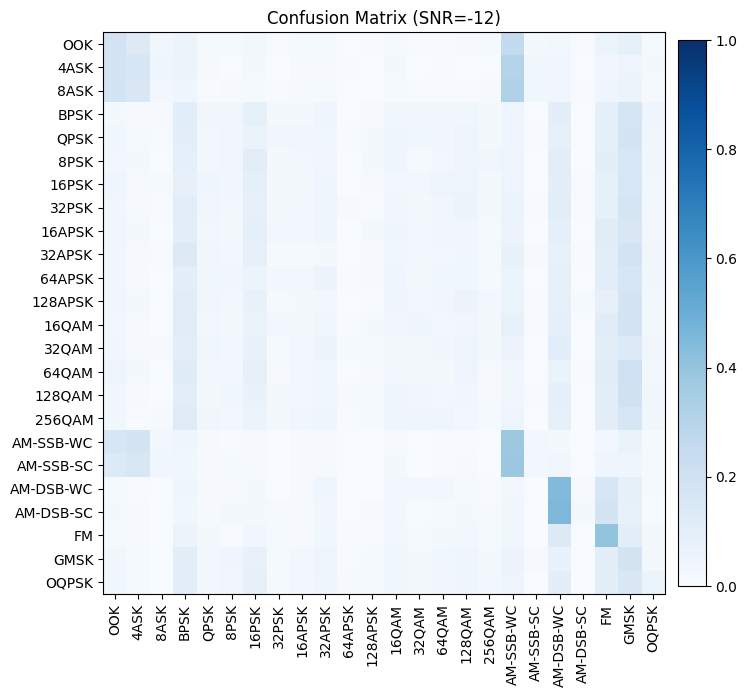

Overall Accuracy -12:  0.09626181021498015
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


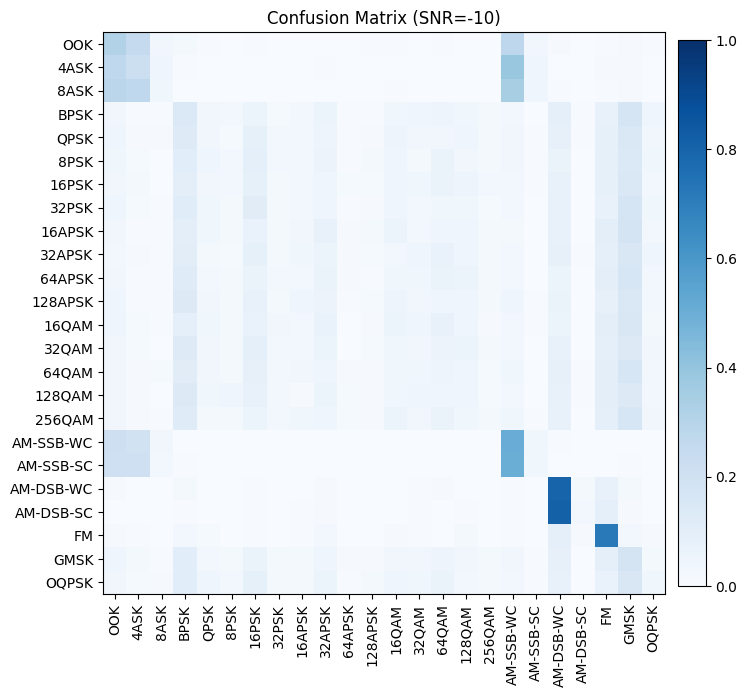

Overall Accuracy -10:  0.14684399117971333
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step


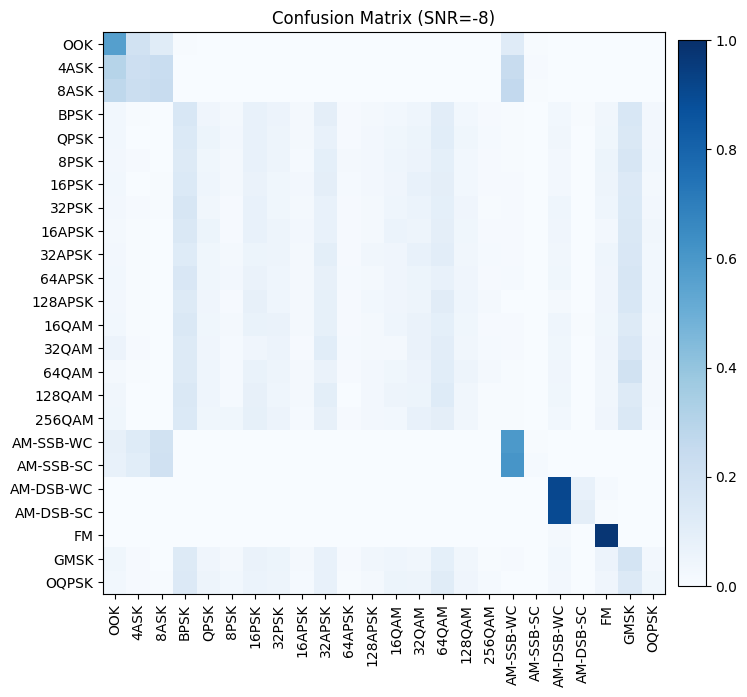

Overall Accuracy -8:  0.18957632817753867
463/463 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


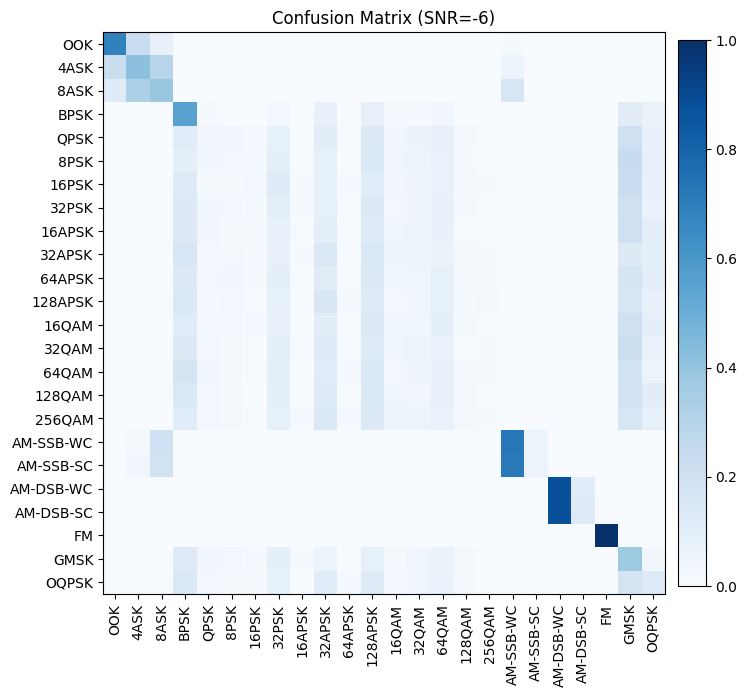

Overall Accuracy -6:  0.24650503140406566
467/467 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


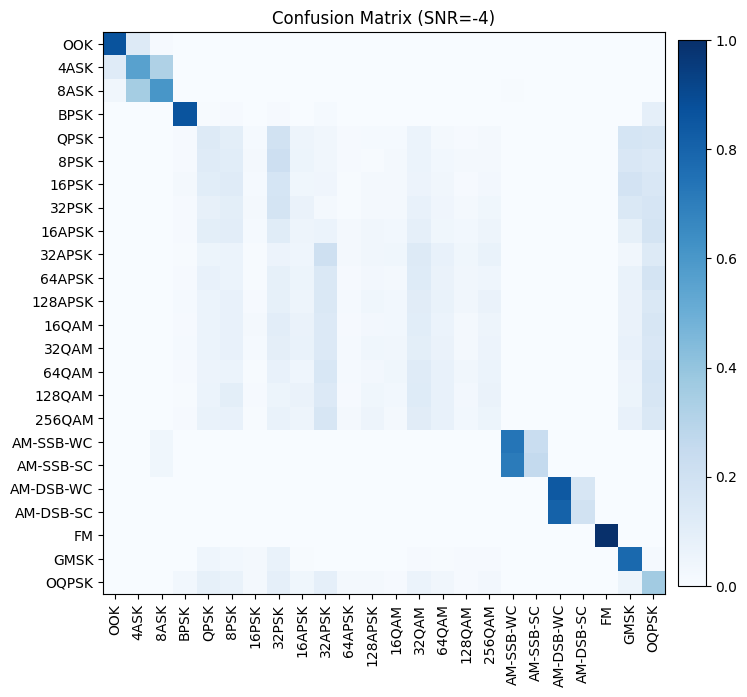

Overall Accuracy -4:  0.3378215434083601
463/463 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step


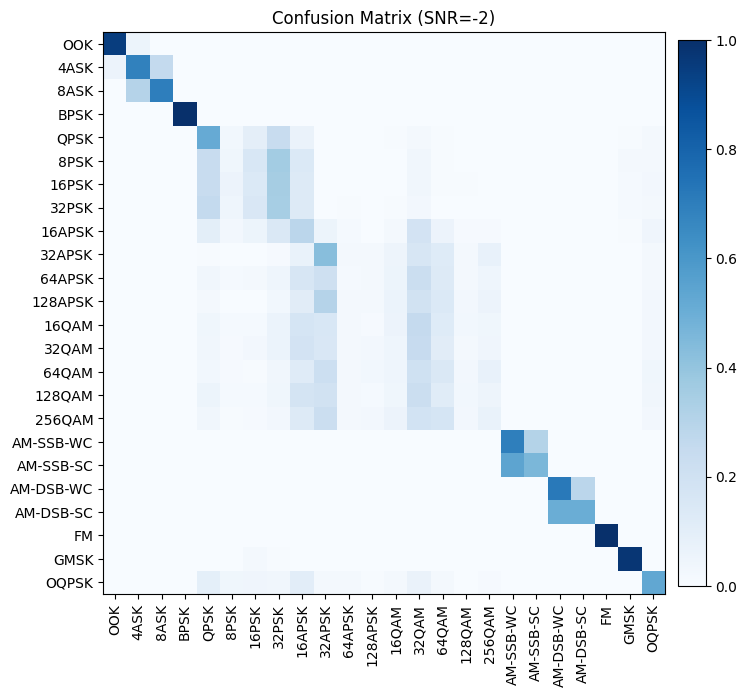

Overall Accuracy -2:  0.43824701195219123
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


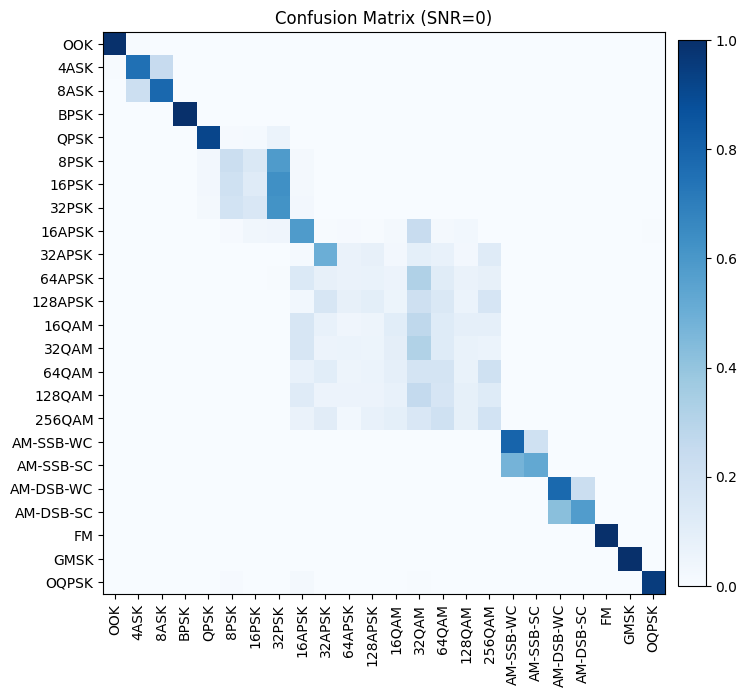

Overall Accuracy 0:  0.5453015616585891
461/461 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step


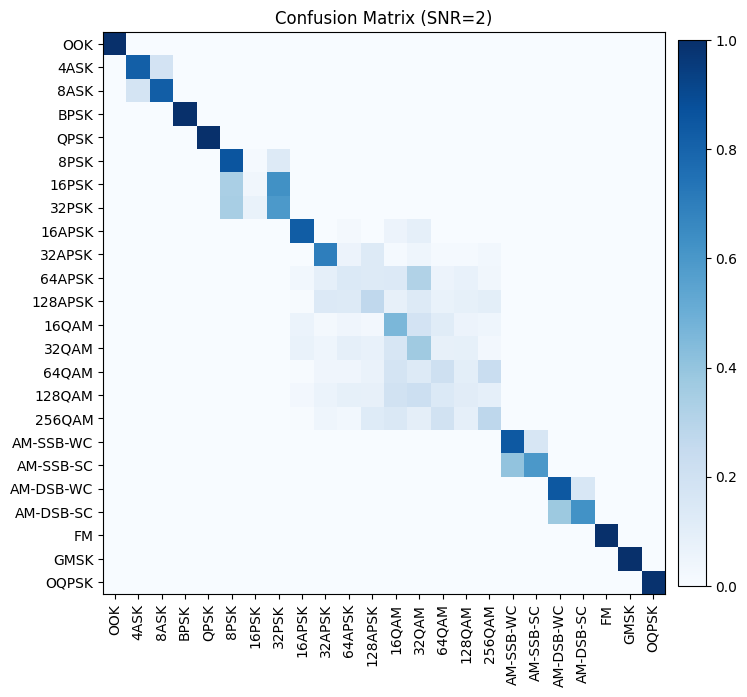

Overall Accuracy 2:  0.6371285113312526
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


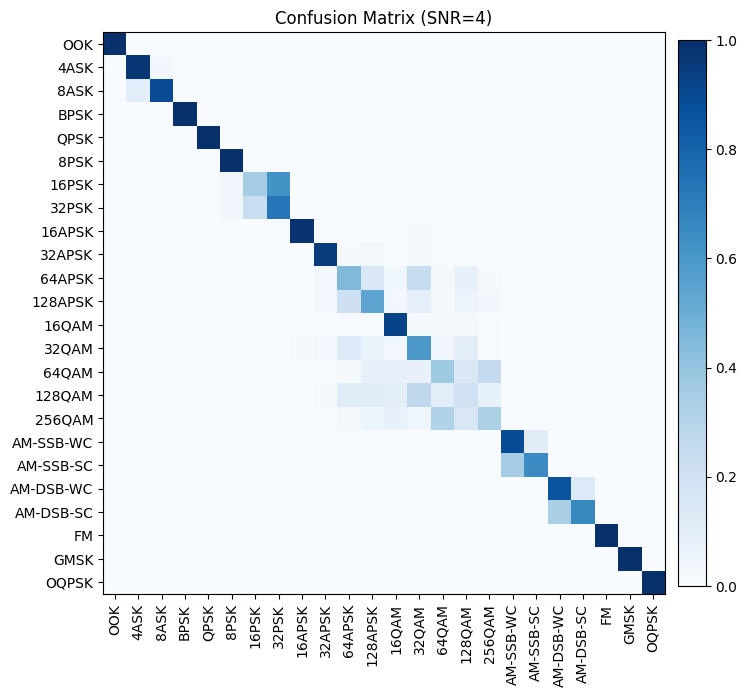

Overall Accuracy 4:  0.7636326363263632
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step


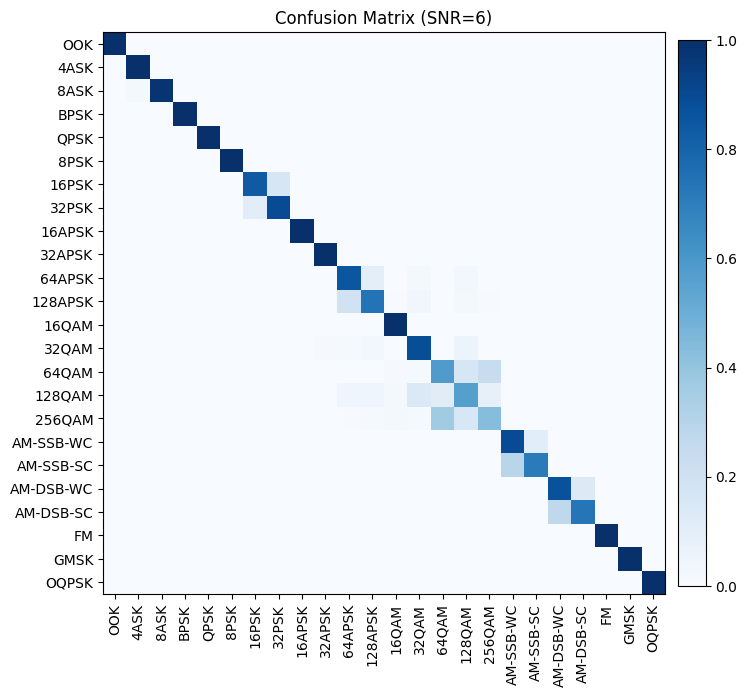

Overall Accuracy 6:  0.874773261672825
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


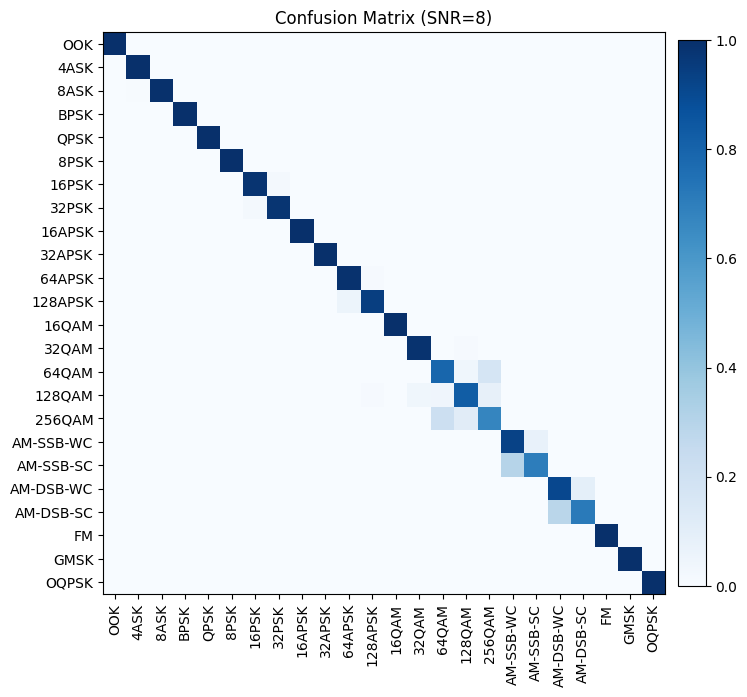

Overall Accuracy 8:  0.9334655361050328
466/466 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


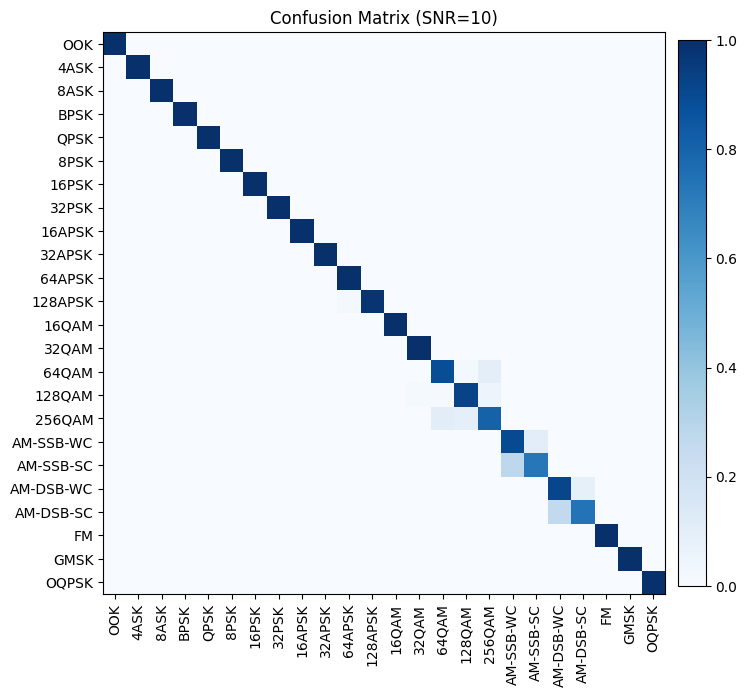

Overall Accuracy 10:  0.9515501274996645
460/460 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


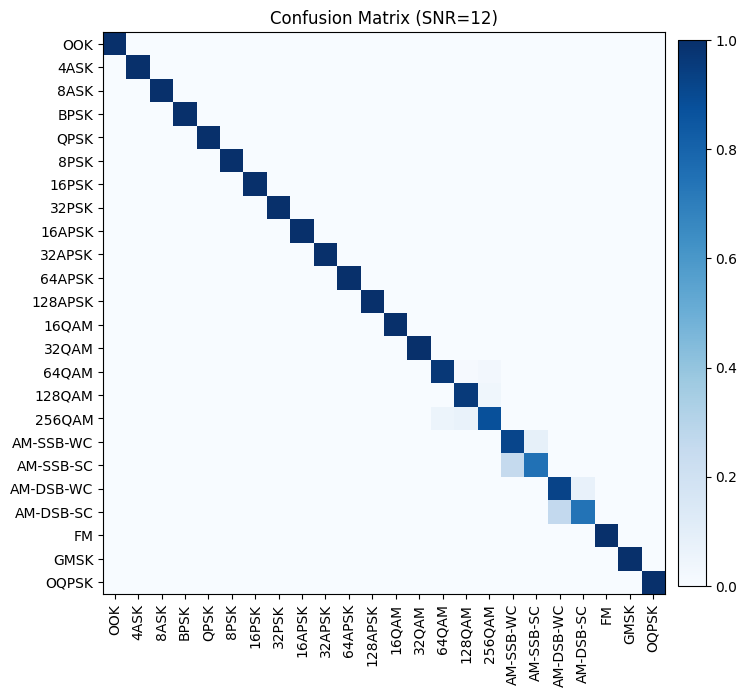

Overall Accuracy 12:  0.9619960568359508
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step


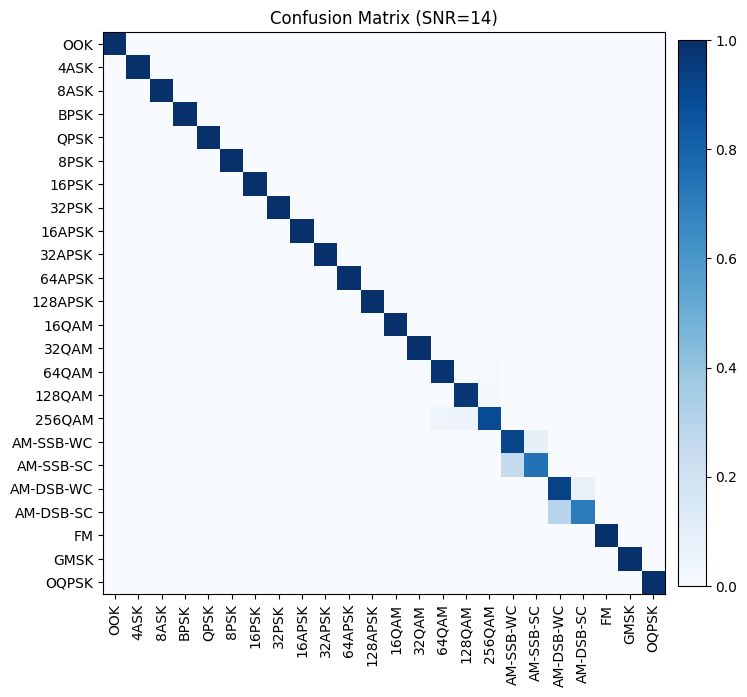

Overall Accuracy 14:  0.9644345838375689
463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


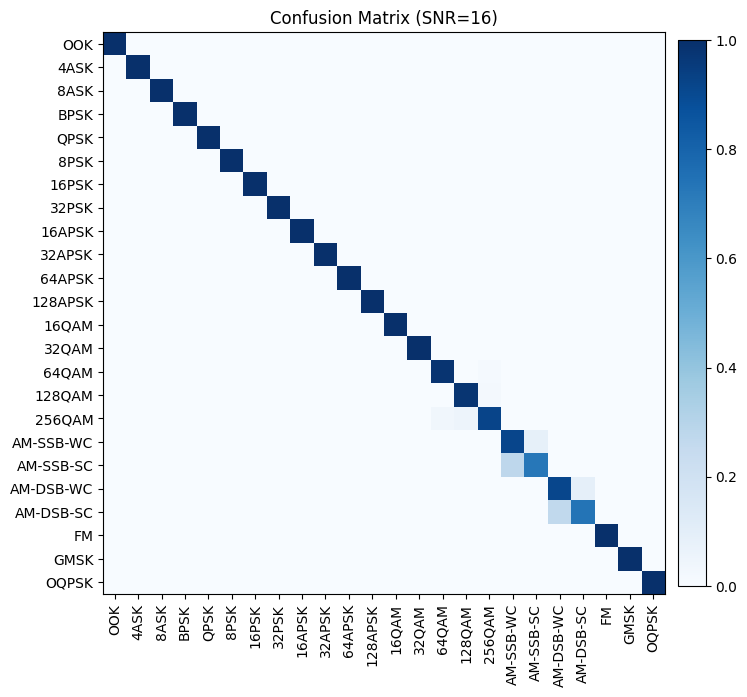

Overall Accuracy 16:  0.9661039837947333
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


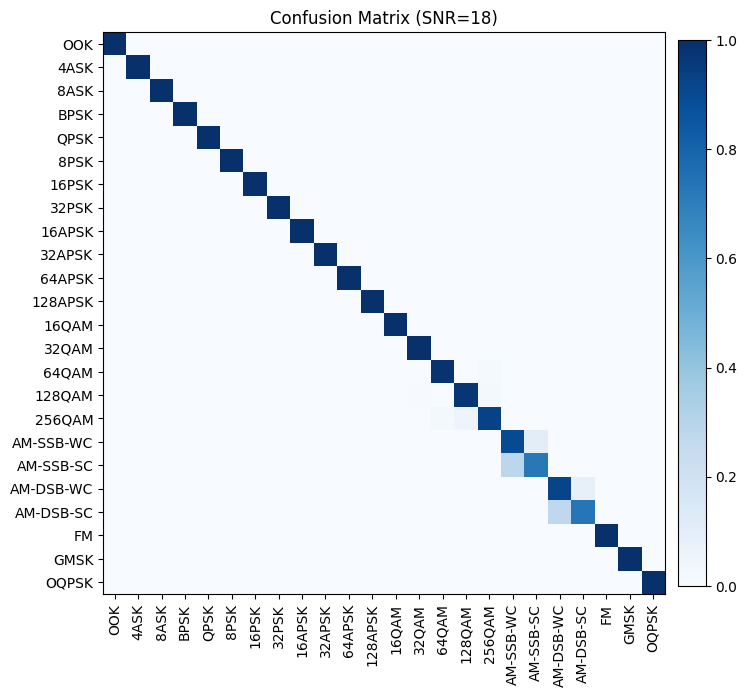

Overall Accuracy 18:  0.9650493421052632
459/459 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


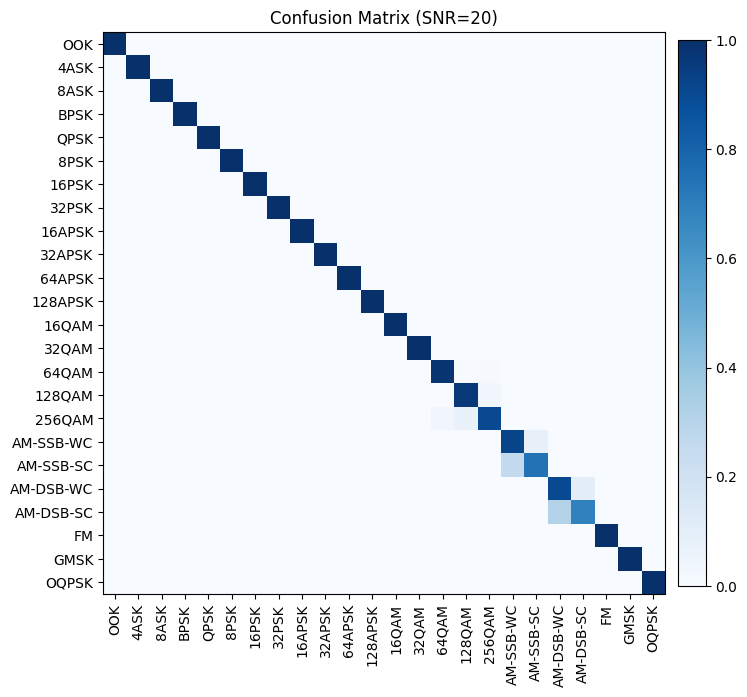

Overall Accuracy 20:  0.9617114048235454
466/466 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


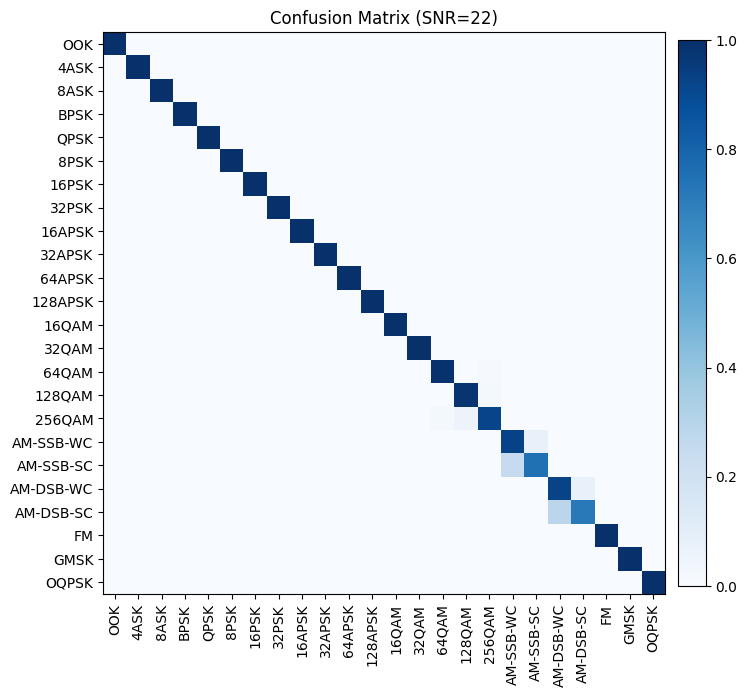

Overall Accuracy 22:  0.9669599086696662
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


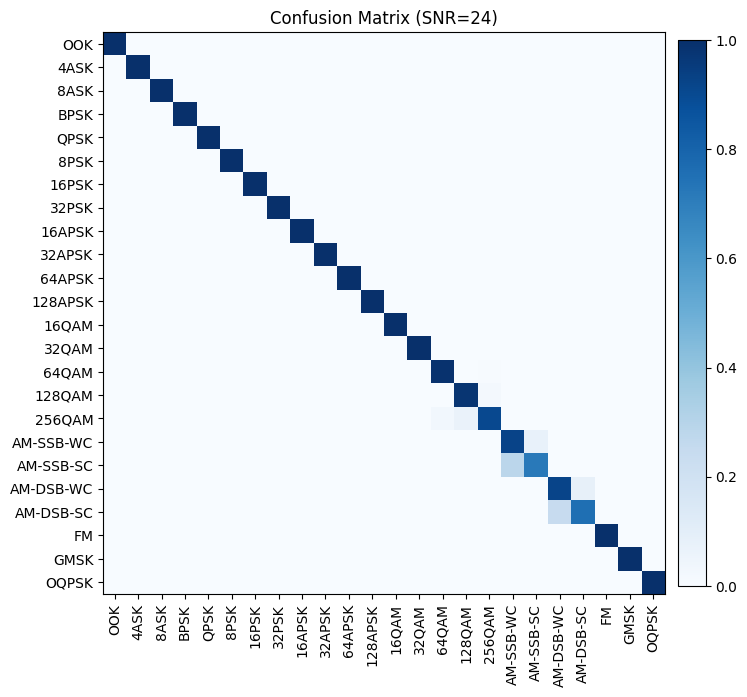

Overall Accuracy 24:  0.9659137577002054
462/462 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


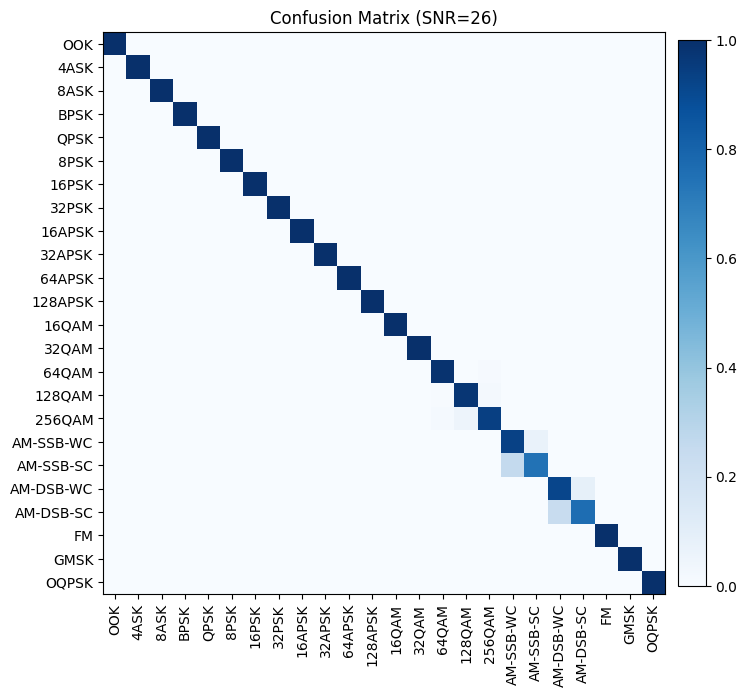

Overall Accuracy 26:  0.9685658153241651
461/461 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


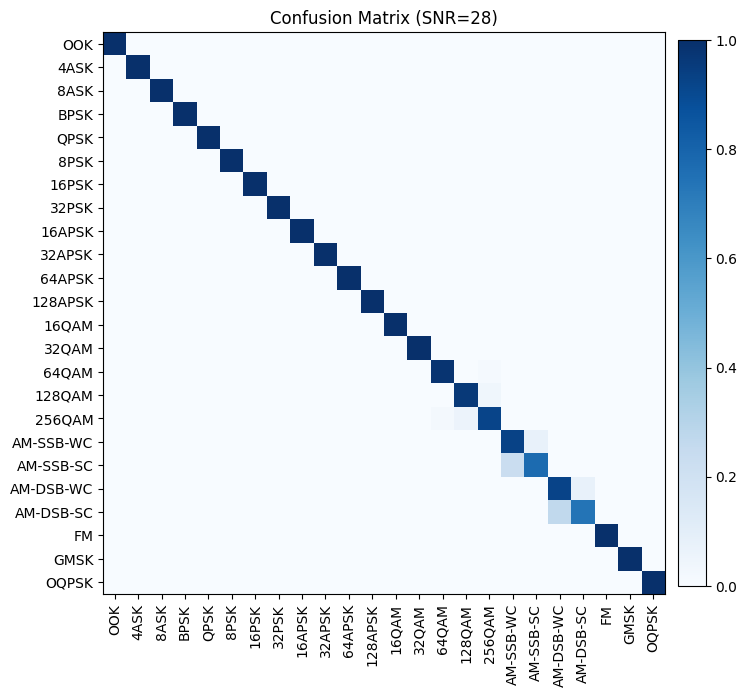

Overall Accuracy 28:  0.9677485062466051
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step


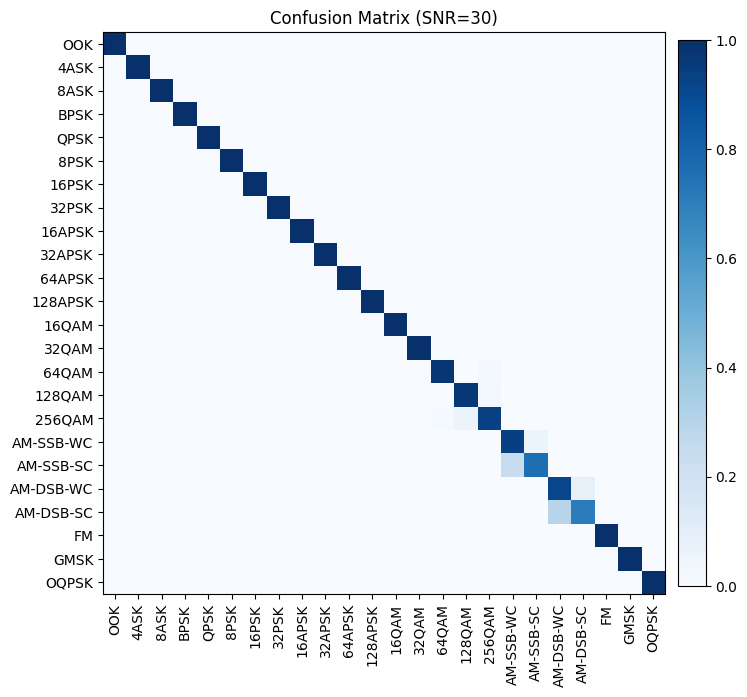

Overall Accuracy 30:  0.9670366633030609


In [12]:
from src.evaluate import evaluate_model_by_snr
path = './Resnet1024_RadioML2018A.keras'
results = evaluate_model_by_snr(model_path=path,
                                class_labels=classes,
                                snr_values=RadioMLConfig.SNR_RANGE,
                                data_gen=test_ds,
                                X_test=X_test,
                                Y_test=Y_test,
                                snr_test=Z_test)

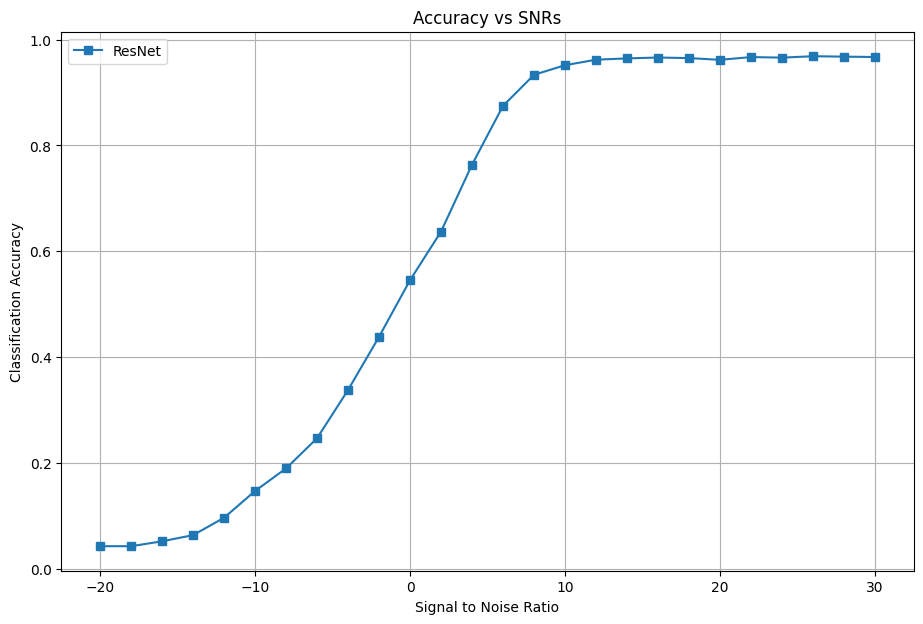

In [14]:
from src.evaluate import plot_accuracy_vs_snr
plot_accuracy_vs_snr(snr_values=RadioMLConfig.SNR_RANGE, 
                     accuracy_values=results,
                     label='ResNet')